,dataset,instance,p,n_vertices,n_hyperedges,initial_objective,final_objective,gammas,betas,optimal_partition,optimal_cost,gap_to_optimal
0,poisson_16_12_3,01,1,12,15,13.113443,7.676082,"[[ 0.83311612],\n [ 0.86704251],\n [ 0.7316471...","[[ 0.30394502],\n [-0.40649124],\n [-0.0280627...",110011001001,6,1.676082
1,poisson_16_12_3,01,2,12,15,13.027771,6.144538,"[[ 9.78694273e-01, 1.32638835e-01],\n [ 4.5953...","[[ 0.24279748, 0.24286322],\n [ 0.04284104,-0....",110011001001,6,0.144538
2,poisson_16_12_3,01,3,12,15,12.928743,6.030821,"[[ 0.28359966, 0.69403407,-0.07465931],\n [ 0....","[[ 2.91104776e-01, 1.52396188e-01, 5.91076381e...",110011001001,6,0.030821
3,poisson_16_12_3,02,1,12,16,11.666846,7.789670,"[[ 8.22470820e-01],\n [ 1.22276193e-01],\n [-1...","[[ 0.97950958],\n [ 0.00573352],\n [-0.1245663...",011100000111,6,1.789670
4,poisson_16_12_3,02,2,12,16,11.595820,6.263831,"[[ 0.4305035 , 0.49265889],\n [ 0.05100941, 0....","[[ 2.17869196e-01, 6.87296666e-01],\n [-1.9763...",011100000111,6,0.263831
5,poisson_16_12_3,02,3,12,16,11.483656,6.068745,"[[ 3.32747407e-01, 3.12392051e-01, 5.96129335e...","[[ 3.61170628e-01, 6.04617023e-01, 1.59534818e...",011100000111,6,0.068745
6,poisson_16_12_3,03,1,12,16,12.716043,10.552764,"[[ 0.48925985],\n [ 1.34354847],\n [ 0.3848764...","[[ 0.31283628],\n [ 0.43362746],\n [ 0.6104136...",100010110011,8,2.552764
7,poisson_16_12_3,03,2,12,16,12.656982,8.452675,"[[ 1.47047113e-01, 3.65645537e-01],\n [ 4.5267...","[[ 0.06130494, 0.11151956],\n [ 0.24468928, 1....",100010110011,8,0.452675
8,poisson_16_12_3,03,3,12,16,12.556038,8.175711,"[[ 6.75228357e-03,-1.46647357e-01, 2.08594461e...","[[ 0.63539755,-0.03882591, 0.67845835],\n [ 0....",100010110011,8,0.175711
9,poisson_16_12_3,04,1,12,16,13.067716,10.905249,"[[ 0.73785127],\n [ 0.99457726],\n [ 0.9364808...","[[ 4.34927332e-01],\n [ 1.51527231e-01],\n [ 2...",101110000101,10,0.905249


Saved results to: poisson_16_12_3_qaoa_with_optimal.csv


p,1,2,3,optimal
instance,,,,
01,7.676082,6.144538,6.030821,6
02,7.789670,6.263831,6.068745,6
03,10.552764,8.452675,8.175711,8
04,10.905249,10.120347,10.029766,10
05,9.177835,7.379823,7.085947,7
06,10.745502,10.113974,10.030299,10
07,9.770237,8.309391,8.053087,8
08,8.069836,7.242131,7.080021,7
09,9.875633,9.199778,9.037406,9


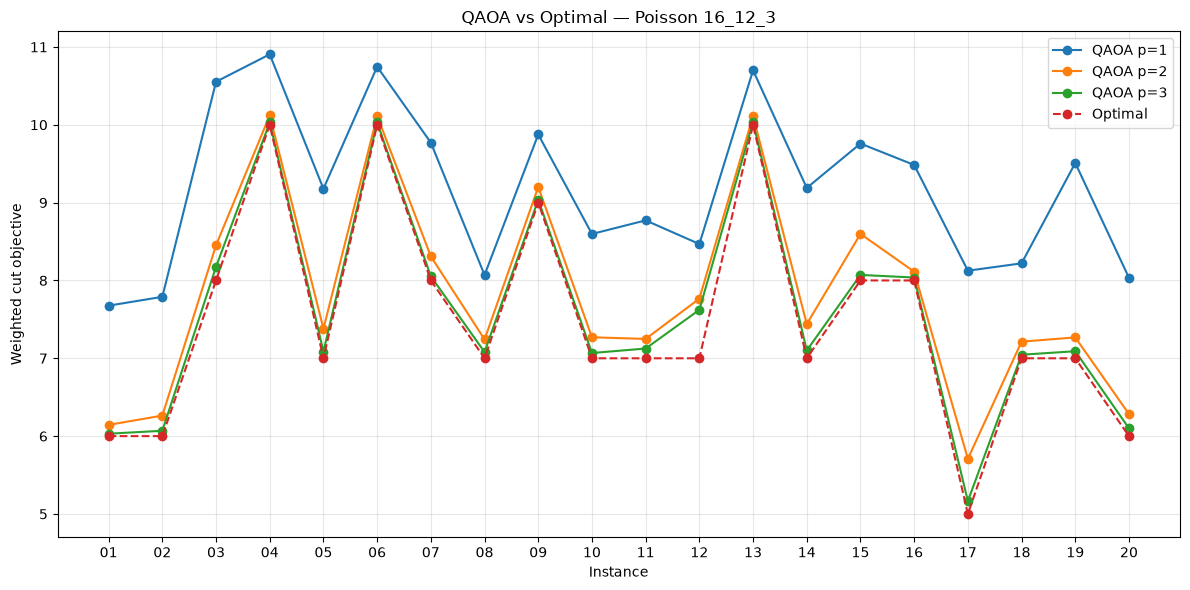

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load QAOA results
# ---------------------------------------------------------

csv_path = "poisson_16_12_3_qaoa_p1_p2_p3.csv"

df = pd.read_csv(csv_path)

# Make sure instance matches strings like "01", "02", ...
df["instance"] = df["instance"].astype(str).str.zfill(2)


# ---------------------------------------------------------
# 2. Optimal Gurobi results
# ---------------------------------------------------------

optimal_results = {
    "01": ("110011001001", 6),
    "02": ("011100000111", 6),
    "03": ("100010110011", 8),
    "04": ("101110000101", 10),
    "05": ("101110100100", 7),
    "06": ("111010000011", 10),
    "07": ("101001001110", 8),
    "08": ("001000011111", 7),
    "09": ("011100010101", 9),
    "10": ("011101000011", 7),
    "11": ("101010100011", 7),
    "12": ("110110010100", 7),
    "13": ("001111001100", 10),
    "14": ("010101000111", 7),
    "15": ("001101011010", 8),
    "16": ("101011010100", 8),
    "17": ("010110101010", 5),
    "18": ("011011100100", 7),
    "19": ("011010001101", 7),
    "20": ("100110010011", 6),
}


# ---------------------------------------------------------
# 3. Add optimal partition and cost to dataframe
# ---------------------------------------------------------

df["optimal_partition"] = df["instance"].map(
    lambda x: optimal_results[x][0]
)

df["optimal_cost"] = df["instance"].map(
    lambda x: optimal_results[x][1]
)

# Optional: difference from optimum
df["gap_to_optimal"] = (
    df["final_objective"] - df["optimal_cost"]
)

display(df)


# ---------------------------------------------------------
# 4. Save enriched dataframe
# ---------------------------------------------------------

output_path = "poisson_16_12_3_qaoa_with_optimal.csv"

df.to_csv(output_path, index=False)

print(f"Saved results to: {output_path}")


# ---------------------------------------------------------
# 5. Reshape for plotting
# ---------------------------------------------------------

plot_df = df.pivot(
    index="instance",
    columns="p",
    values="final_objective"
)

# Add optimal value once per instance
optimal_series = (
    df.drop_duplicates("instance")
      .set_index("instance")["optimal_cost"]
)

plot_df["optimal"] = optimal_series

display(plot_df)


# ---------------------------------------------------------
# 6. Plot p=1, p=2, p=3 versus exact optimum
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    plot_df.index,
    plot_df[1],
    marker="o",
    label="QAOA p=1"
)

plt.plot(
    plot_df.index,
    plot_df[2],
    marker="o",
    label="QAOA p=2"
)

plt.plot(
    plot_df.index,
    plot_df[3],
    marker="o",
    label="QAOA p=3"
)

plt.plot(
    plot_df.index,
    plot_df["optimal"],
    marker="o",
    linestyle="--",
    label="Optimal"
)

plt.xlabel("Instance")
plt.ylabel("Weighted cut objective")
plt.title("QAOA vs Optimal — Poisson 16_12_3")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()